# Modelos de Clasificación — Rezago Académico por Área en Saber 11 (Bolívar)
**Proyecto 2 — Analítica Computacional para la Toma de Decisiones**  
**Universidad de los Andes**  
**Autor:** Daniel David Burgos Lafont  

## Contexto

Familia de cinco modelos de clasificación binaria que estiman la probabilidad de **rezago académico** en cada área del Saber 11 para estudiantes del departamento de Bolívar. El **modelo oficial del proyecto y del futuro dashboard es una red neuronal en TensorFlow/Keras**. Se mantienen como modelos comparativos `LogisticRegression` (baseline) y `HistGradientBoostingClassifier` (benchmark).

## Pregunta de negocio

> ¿En qué áreas del Saber 11 presentan los estudiantes mayor probabilidad de rezago académico, y cómo puede la Secretaría de Educación de Bolívar priorizar intervenciones diferenciadas por competencia según el perfil socioeconómico, familiar y escolar del estudiante?

## Definición operativa de rezago

$$\text{rezago\_area}_i = 1 \quad \text{si} \quad \text{punt\_area}_i \le P_{25}^{\text{train}}(\text{punt\_area})$$

$P_{25}$ se calcula **solo sobre el conjunto de entrenamiento** para evitar fuga del test al definir el umbral.

## 1. Imports y configuración

In [1]:
import sys
!{sys.executable} -m pip install tensorflow pandas numpy scikit-learn matplotlib mlflow joblib
import os
import json
import random
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import joblib
import mlflow

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# No silenciamos warnings globalmente. Solo eliminamos FutureWarning (ruido).
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
# Reducir verbosidad de TF en consola
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Semilla
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

print(f"Python      : {platform.python_version()}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"tensorflow  : {tf.__version__}")
print(f"mlflow      : {mlflow.__version__}")



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Python      : 3.12.0
pandas      : 2.3.3
scikit-learn: 1.8.0
tensorflow  : 2.21.0
mlflow      : 3.12.0


## 2. Carga del CSV limpio

In [2]:
df = pd.read_csv("DatosSaber11_Bolivar_limpio_todas_columnas.csv")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()


Filas: 122,866
Columnas: 52


,estu_consecutivo,periodo,estu_fechanacimiento,edad,estu_genero,cole_area_ubicacion,cole_mcpio_ubicacion,cole_calendario,cole_bilingue,cole_naturaleza,cole_genero,cole_caracter,fami_estratovivienda,fami_tienecomputador,fami_tieneinternet,fami_educacionmadre,fami_educacionpadre,punt_ingles,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_global,estu_tipodocumento,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_jornada,cole_nombre_establecimiento,cole_nombre_sede,cole_sede_principal,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,estu_depto_presentacion,estu_depto_reside,estu_estadoinvestigacion,estu_estudiante,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,estu_pais_reside,estu_privado_libertad,fami_cuartoshogar,fami_personashogar,fami_tieneautomovil,fami_tienelavadora,desemp_ingles
0,SB11202240343561,20224,20/05/2005,17,M,URBANO,ARJONA,A,N,OFICIAL,MIXTO,ACADEMICO,ESTRATO 1,NO,NO,SECUNDARIA (BACHILLERATO) COMPLETA,PRIMARIA COMPLETA,51.0,47.0,49,51,32,226.0,TI,113052000172,113052000172,13,13052,4499,BOLIVAR,MAÑANA,INSTITUCIÓN EDUCATIVA BENJAMIN HERRERA,I.E. BENJAMIN HERRERA - SEDE PRINCIPAL,S,13,13052,13,13052,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,ARJONA,ARJONA,COLOMBIA,COLOMBIA,N,Uno,3 a 4,No,Si,A1
1,SB11202240223211,20224,07/07/2005,17,M,URBANO,CARTAGENA DE INDIAS,A,N,OFICIAL,MIXTO,TECNICO/ACADEMICO,ESTRATO 3,SI,SI,EDUCACION PROFESIONAL COMPLETA,EDUCACION PROFESIONAL COMPLETA,100.0,62.0,68,67,71,348.0,TI,113001003053,113001003053,13,13001,4481,BOLIVAR,TARDE,INSTITUCION EDUCATIVA SOLEDAD ACOSTA DE SAMPER,INSTITUCION EDUCATIVA SOLEDAD ACOSTA DE SAMPER,S,13,13001,13,13001,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,CARTAGENA DE INDIAS,CARTAGENA DE INDIAS,COLOMBIA,COLOMBIA,N,Tres,5 a 6,No,Si,B+
2,SB11202240503276,20224,27/05/2006,16,F,URBANO,SAN JACINTO DEL CAUCA,A,N,OFICIAL,MIXTO,ACADEMICO,ESTRATO 3,NO,NO,SECUNDARIA (BACHILLERATO) COMPLETA,NINGUNO,39.0,26.0,36,39,25,160.0,TI,213006001649,213006001649,13,13655,86751,BOLIVAR,MAÑANA,INSTITUCION EDUCATIVA PLACIDO RETAMOZA,INSTITUCION EDUCATIVA PLACIDO RETAMOZA,S,5,5495,13,13655,ANTIOQUIA,BOLIVAR,PUBLICAR,ESTUDIANTE,NECHÍ,SAN JACINTO DEL CAUCA,COLOMBIA,COLOMBIA,N,Tres,3 a 4,No,Si,A-
3,SB11202240231496,20224,05/05/2005,17,M,RURAL,CARTAGENA DE INDIAS,A,N,OFICIAL,MIXTO,ACADEMICO,SIN ESTRATO,NO,SI,SECUNDARIA (BACHILLERATO) COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,42.0,25.0,35,36,32,164.0,TI,213001027020,213001027020,13,13001,314641,BOLIVAR,MAÑANA,INSTITUCION EDUCATIVA DOMINGO BENKOS BIOHO,INSTITUCION EDUCATIVA DOMINGO BENKOS BIOHO,S,13,13001,13,13001,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,CARTAGENA DE INDIAS,CARTAGENA DE INDIAS,COLOMBIA,COLOMBIA,N,Dos,3 a 4,No,Si,A-
4,SB11202240177303,20224,24/09/2004,18,F,URBANO,CARTAGENA DE INDIAS,A,N,OFICIAL,MIXTO,ACADEMICO,ESTRATO 1,SI,SI,TECNICA O TECNOLOGICA INCOMPLETA,TECNICA O TECNOLOGICA INCOMPLETA,45.0,52.0,52,51,48,252.0,TI,113001000348,113001000348,13,13001,142539,BOLIVAR,NOCHE,INSTITUCION EDUCATIVA AMBIENTALISTA DE CARTAGENA,INSTITUCION EDUCATIVA AMBIENTALISTA DE CARTAGENA,S,13,13001,13,13001,BOLIVAR,BOLIVAR,PUBLICAR,ESTUDIANTE,CARTAGENA DE INDIAS,CARTAGENA DE INDIAS,COLOMBIA,COLOMBIA,N,Tres,3 a 4,No,Si,A-


## 3. Revisión de tipos y columnas

In [3]:
print("Tipos de datos:")
print(df.dtypes)
print(f"\nNulos totales: {int(df.isna().sum().sum())}")
print(f"Filas duplicadas: {int(df.duplicated().sum())}")


Tipos de datos:
estu_consecutivo                  object
periodo                            int64
estu_fechanacimiento              object
edad                               int64
estu_genero                       object
cole_area_ubicacion               object
cole_mcpio_ubicacion              object
cole_calendario                   object
cole_bilingue                     object
cole_naturaleza                   object
cole_genero                       object
cole_caracter                     object
fami_estratovivienda              object
fami_tienecomputador              object
fami_tieneinternet                object
fami_educacionmadre               object
fami_educacionpadre               object
punt_ingles                      float64
punt_matematicas                 float64
punt_lectura_critica               int64
punt_c_naturales                   int64
punt_sociales_ciudadanas           int64
punt_global                      float64
estu_tipodocumento                object


## 4. Exploración inicial de los puntajes por área

In [4]:
areas_puntaje = {
    "Matemáticas":           "punt_matematicas",
    "Lectura Crítica":       "punt_lectura_critica",
    "Ciencias Naturales":    "punt_c_naturales",
    "Sociales y Ciudadanas": "punt_sociales_ciudadanas",
    "Inglés":                "punt_ingles",
}
df[list(areas_puntaje.values())].describe().round(2)


,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles
count,122866.00,122866.00,122866.00,122866.00,122866.00
mean,47.07,48.85,47.19,45.77,47.34
std,11.58,10.38,10.30,11.48,11.40
min,0.00,0.00,0.00,0.00,0.00
25%,39.00,41.00,40.00,37.00,40.00
50%,46.00,48.00,46.00,45.00,45.00
75%,54.00,56.00,54.00,53.00,52.00
max,100.00,100.00,100.00,100.00,100.00


## 5. Selección de predictores

Excluimos cualquier columna cuyo nombre empiece por `punt_`, `desemp_`, `percentil_`, `decil_`, `cuartil_` o `rezago_`, más identificadores y fechas crudas.


In [5]:
PREDICTORES_SUGERIDOS = [
    "edad", "periodo",
    "estu_genero",
    "cole_area_ubicacion", "cole_mcpio_ubicacion", "cole_calendario", "cole_bilingue",
    "cole_naturaleza", "cole_genero", "cole_caracter", "cole_jornada",
    "fami_estratovivienda", "fami_tienecomputador", "fami_tieneinternet",
    "fami_tieneautomovil", "fami_tienelavadora",
    "fami_educacionmadre", "fami_educacionpadre",
    "fami_cuartoshogar", "fami_personashogar",
]

EXCLUSIONES_EXPLICITAS = {
    "punt_global", "punt_matematicas", "punt_lectura_critica",
    "punt_c_naturales", "punt_sociales_ciudadanas", "punt_ingles",
    "desemp_ingles",
    "estu_consecutivo", "estu_fechanacimiento",
}

PREFIJOS_PROHIBIDOS = ("punt_", "desemp_", "percentil_", "decil_", "cuartil_", "rezago_")


def es_predictor_valido(col, exclusiones_extra=None):
    exclusiones_extra = exclusiones_extra or set()
    if col in EXCLUSIONES_EXPLICITAS or col in exclusiones_extra:
        return False
    for pref in PREFIJOS_PROHIBIDOS:
        if col.startswith(pref):
            return False
    return True


disponibles = [c for c in PREDICTORES_SUGERIDOS if c in df.columns]
predictores = [c for c in disponibles if es_predictor_valido(c)]
descartados = [c for c in PREDICTORES_SUGERIDOS if c not in df.columns]

print(f"Predictores finales ({len(predictores)}):")
for p in predictores:
    print(f"  - {p}")
if descartados:
    print(f"\nSugeridos NO encontrados en CSV: {descartados}")

# Anti-fuga assert
malos = [c for c in predictores if any(c.startswith(p) for p in PREFIJOS_PROHIBIDOS)
         or c in EXCLUSIONES_EXPLICITAS]
assert len(malos) == 0, f"FUGA DETECTADA en predictores: {malos}"
print("\n[OK] Verificación anti-fuga.")


Predictores finales (20):
  - edad
  - periodo
  - estu_genero
  - cole_area_ubicacion
  - cole_mcpio_ubicacion
  - cole_calendario
  - cole_bilingue
  - cole_naturaleza
  - cole_genero
  - cole_caracter
  - cole_jornada
  - fami_estratovivienda
  - fami_tienecomputador
  - fami_tieneinternet
  - fami_tieneautomovil
  - fami_tienelavadora
  - fami_educacionmadre
  - fami_educacionpadre
  - fami_cuartoshogar
  - fami_personashogar

[OK] Verificación anti-fuga.


In [ ]:
PREDICTORES_SUGERIDOS = [
    "edad", "periodo",
    "estu_genero",
    "cole_area_ubicacion", "cole_mcpio_ubicacion", "cole_calendario", "cole_bilingue",
    "cole_naturaleza", "cole_genero", "cole_caracter", "cole_jornada",
    "fami_estratovivienda", "fami_tienecomputador", "fami_tieneinternet",
    "fami_tieneautomovil", "fami_tienelavadora",
    "fami_educacionmadre", "fami_educacionpadre",
    "fami_cuartoshogar", "fami_personashogar",
]

EXCLUSIONES_EXPLICITAS = {
    "punt_global", "punt_matematicas", "punt_lectura_critica",
    "punt_c_naturales", "punt_sociales_ciudadanas", "punt_ingles",
    "desemp_ingles",
    "estu_consecutivo", "estu_fechanacimiento",
}

PREFIJOS_PROHIBIDOS = ("punt_", "desemp_", "percentil_", "decil_", "cuartil_", "rezago_")


def es_predictor_valido(col, exclusiones_extra=None):
    exclusiones_extra = exclusiones_extra or set()
    if col in EXCLUSIONES_EXPLICITAS or col in exclusiones_extra:
        return False
    for pref in PREFIJOS_PROHIBIDOS:
        if col.startswith(pref):
            return False
    return True


disponibles = [c for c in PREDICTORES_SUGERIDOS if c in df.columns]
predictores = [c for c in disponibles if es_predictor_valido(c)]
descartados = [c for c in PREDICTORES_SUGERIDOS if c not in df.columns]

print(f"Predictores finales ({len(predictores)}):")
for p in predictores:
    print(f"  - {p}")
if descartados:
    print(f"\nSugeridos NO encontrados en CSV: {descartados}")

# Anti-fuga assert
malos = [c for c in predictores if any(c.startswith(p) for p in PREFIJOS_PROHIBIDOS)
         or c in EXCLUSIONES_EXPLICITAS]
assert len(malos) == 0, f"FUGA DETECTADA en predictores: {malos}"
print("\n[OK] Verificación anti-fuga.")


Predictores finales (20):
  - edad
  - periodo
  - estu_genero
  - cole_area_ubicacion
  - cole_mcpio_ubicacion
  - cole_calendario
  - cole_bilingue
  - cole_naturaleza
  - cole_genero
  - cole_caracter
  - cole_jornada
  - fami_estratovivienda
  - fami_tienecomputador
  - fami_tieneinternet
  - fami_tieneautomovil
  - fami_tienelavadora
  - fami_educacionmadre
  - fami_educacionpadre
  - fami_cuartoshogar
  - fami_personashogar

[OK] Verificación anti-fuga.


## 6. Tipos numéricos vs categóricos y cardinalidad

In [6]:
cols_numericas = [c for c in ["edad", "periodo"] if c in predictores]
cols_categoricas = [c for c in predictores if c not in cols_numericas]

df_modelo = df[predictores + list(areas_puntaje.values())].copy()
for c in cols_numericas:
    df_modelo[c] = pd.to_numeric(df_modelo[c], errors="coerce")
for c in cols_categoricas:
    df_modelo[c] = df_modelo[c].astype(str)

print(f"Numéricas   ({len(cols_numericas)}): {cols_numericas}")
print(f"Categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print("\nCardinalidad de categóricas:")
for c in sorted(cols_categoricas, key=lambda x: -df_modelo[x].nunique()):
    n = df_modelo[c].nunique()
    flag = "  [alta]" if n > 50 else ""
    print(f"  {c:30s}: {n:4d} categorías{flag}")


Numéricas   (2): ['edad', 'periodo']
Categóricas (18): ['estu_genero', 'cole_area_ubicacion', 'cole_mcpio_ubicacion', 'cole_calendario', 'cole_bilingue', 'cole_naturaleza', 'cole_genero', 'cole_caracter', 'cole_jornada', 'fami_estratovivienda', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tieneautomovil', 'fami_tienelavadora', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_cuartoshogar', 'fami_personashogar']

Cardinalidad de categóricas:
  cole_mcpio_ubicacion          :   47 categorías
  fami_personashogar            :   17 categorías
  fami_educacionmadre           :   12 categorías
  fami_educacionpadre           :   12 categorías
  fami_cuartoshogar             :   11 categorías
  fami_estratovivienda          :    7 categorías
  cole_jornada                  :    6 categorías
  cole_caracter                 :    4 categorías
  cole_genero                   :    3 categorías
  estu_genero                   :    2 categorías
  cole_area_ubicacion           :    2 catego

## 7. Partición train/test única y cálculo de $P_{25}$ solo sobre train

In [7]:
X_full = df_modelo[predictores].copy()

idx_train, idx_test = train_test_split(
    np.arange(len(df_modelo)),
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)
print(f"Train: {len(idx_train):,} filas")
print(f"Test : {len(idx_test):,} filas")

X_train = X_full.iloc[idx_train].copy()
X_test  = X_full.iloc[idx_test].copy()

mapeo_targets = {
    "Matemáticas":           ("punt_matematicas",          "rezago_matematicas"),
    "Lectura Crítica":       ("punt_lectura_critica",      "rezago_lectura_critica"),
    "Ciencias Naturales":    ("punt_c_naturales",          "rezago_c_naturales"),
    "Sociales y Ciudadanas": ("punt_sociales_ciudadanas",  "rezago_sociales_ciudadanas"),
    "Inglés":                ("punt_ingles",               "rezago_ingles"),
}

y_train_dict = {}
y_test_dict = {}
percentiles_25_train = {}

print("\nP25 calculado sobre TRAIN:")
print(f"{'Área':25s}  {'P25_train':>10s}  {'%_rezago_train':>14s}  {'%_rezago_test':>14s}")
for nombre_area, (col_punt, target) in mapeo_targets.items():
    puntaje_train = df_modelo.iloc[idx_train][col_punt]
    puntaje_test  = df_modelo.iloc[idx_test][col_punt]
    p25 = float(puntaje_train.quantile(0.25))
    percentiles_25_train[nombre_area] = p25
    y_train_dict[target] = (puntaje_train.values <= p25).astype(int)
    y_test_dict[target]  = (puntaje_test.values  <= p25).astype(int)
    pct_train = y_train_dict[target].mean() * 100
    pct_test  = y_test_dict[target].mean() * 100
    print(f"{nombre_area:25s}  {p25:10.2f}  {pct_train:13.2f}%  {pct_test:13.2f}%")

# Construimos un dataframe combinando target etiquetado en TODO el df (con P25 de train)
# para EDA exploratorio posterior por categorias.
df_eda = df_modelo.copy()
for nombre_area, (col_punt, target) in mapeo_targets.items():
    df_eda[target] = (df_eda[col_punt] <= percentiles_25_train[nombre_area]).astype(int)


Train: 98,292 filas
Test : 24,574 filas

P25 calculado sobre TRAIN:
Área                        P25_train  %_rezago_train   %_rezago_test
Matemáticas                     39.00          26.89%          26.68%
Lectura Crítica                 41.00          26.52%          26.52%
Ciencias Naturales              40.00          27.64%          27.83%
Sociales y Ciudadanas           37.00          25.78%          25.89%
Inglés                          40.00          27.42%          26.96%


## 8. Distribución de puntajes por área con línea del $P_{25}$

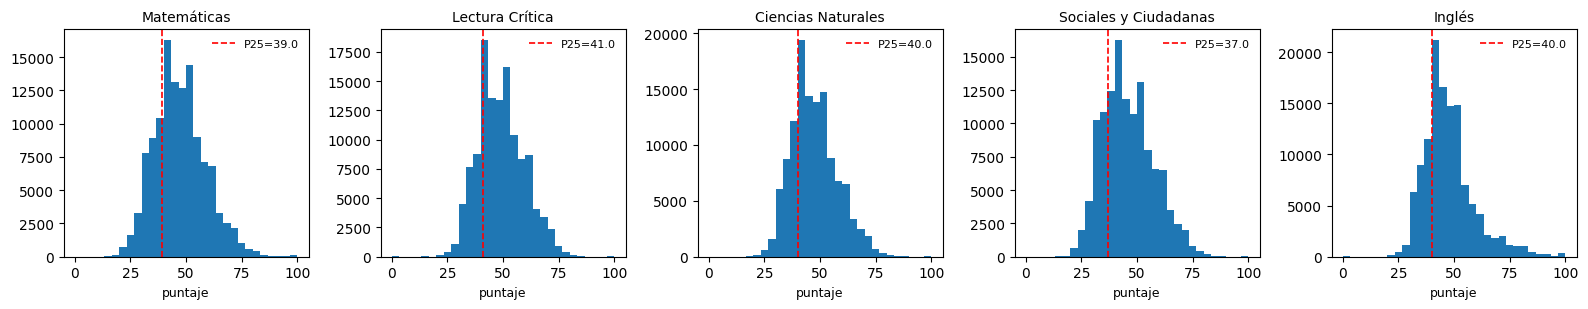

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, (nombre_area, (col_punt, _)) in zip(axes, mapeo_targets.items()):
    serie = df_modelo[col_punt].dropna()
    p25 = percentiles_25_train[nombre_area]
    ax.hist(serie, bins=30)
    ax.axvline(p25, color="red", linestyle="--", linewidth=1.2,
               label=f"P25={p25:.1f}")
    ax.set_title(nombre_area, fontsize=10)
    ax.set_xlabel("puntaje", fontsize=9)
    ax.legend(loc="upper right", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


## 9. Balance de clases por área (train vs test)

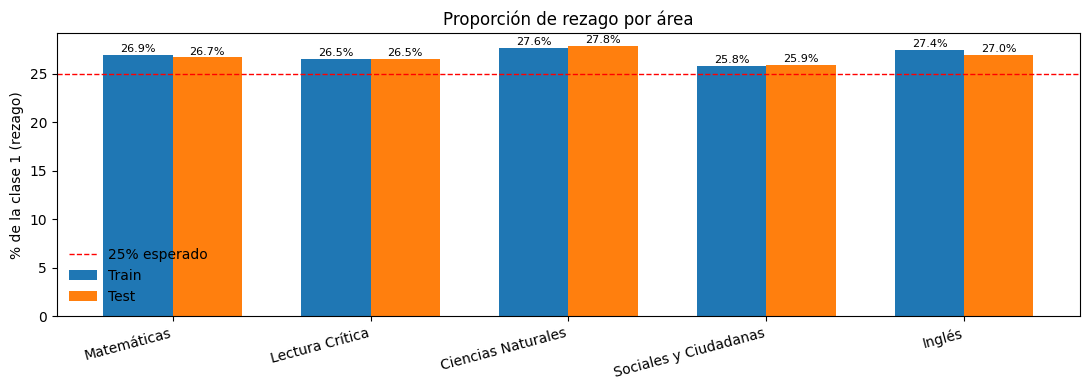

In [9]:
nombres_areas = list(mapeo_targets.keys())
targets_list = [mapeo_targets[a][1] for a in nombres_areas]
pct_train = [y_train_dict[t].mean() * 100 for t in targets_list]
pct_test  = [y_test_dict[t].mean()  * 100 for t in targets_list]

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(nombres_areas))
w = 0.35
b1 = ax.bar(x - w/2, pct_train, w, label="Train")
b2 = ax.bar(x + w/2, pct_test,  w, label="Test")
for bars, vals in [(b1, pct_train), (b2, pct_test)]:
    for bb, v in zip(bars, vals):
        ax.text(bb.get_x() + bb.get_width()/2, v + 0.3, f"{v:.1f}%",
                ha="center", fontsize=8)
ax.axhline(25, color="red", linestyle="--", linewidth=1, label="25% esperado")
ax.set_xticks(x); ax.set_xticklabels(nombres_areas, rotation=15, ha="right")
ax.set_ylabel("% de la clase 1 (rezago)")
ax.set_title("Proporción de rezago por área")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 10. Análisis exploratorio: rezago promedio por categoría

Tasa promedio de rezago (clase 1) según variables socioeconómicas, familiares y escolares. Sirve para conectar el modelo con la pregunta de negocio: las variables del entorno sí parecen estar asociadas con el rezago en las distintas áreas.


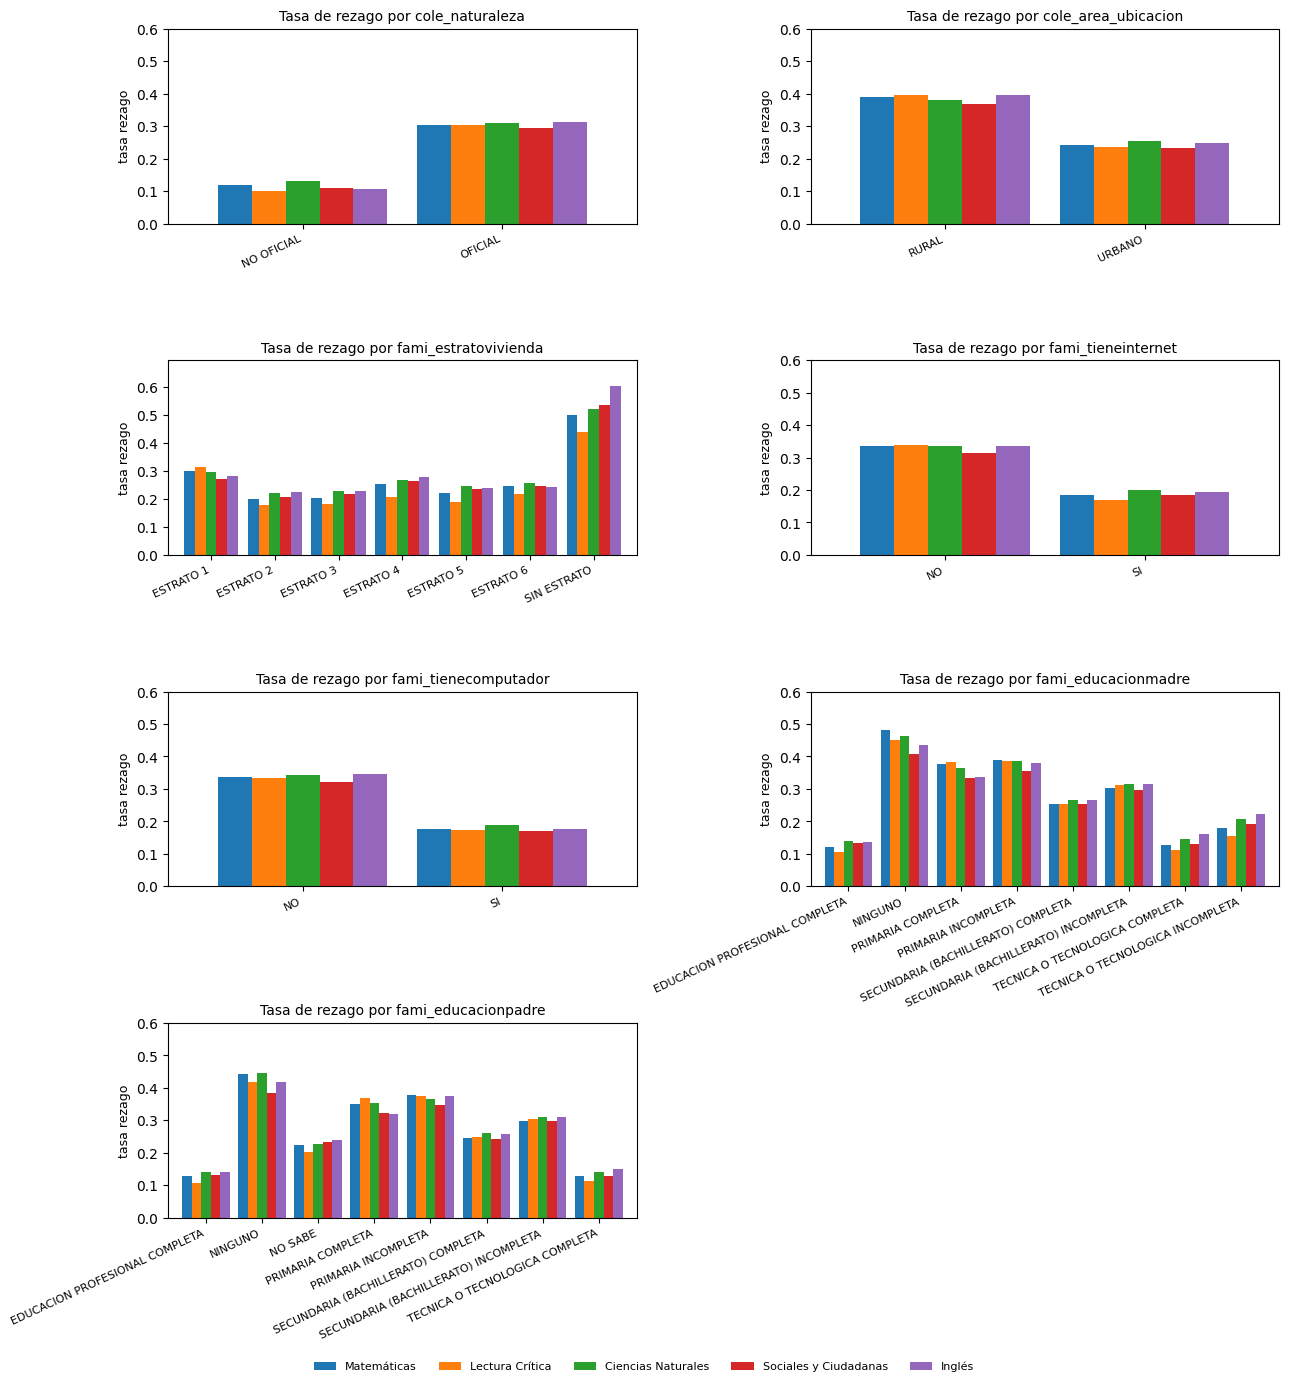

In [10]:
def rezago_promedio_por_categoria(df_eda, variable, targets_list, nombres_areas, max_cats=10):
    """Devuelve un DataFrame con la tasa promedio de rezago por nivel de la variable."""
    if variable not in df_eda.columns:
        return None
    grp = df_eda.groupby(variable)[targets_list].mean()
    # Recorta a las top categorias por tamano si hay demasiadas
    if grp.shape[0] > max_cats:
        top_cats = df_eda[variable].value_counts().nlargest(max_cats).index
        grp = grp.loc[grp.index.intersection(top_cats)]
    grp.columns = nombres_areas
    return grp.sort_index()


def plot_rezago_categorias(df_eda, variable, targets_list, nombres_areas, ax, max_cats=10):
    tabla = rezago_promedio_por_categoria(df_eda, variable, targets_list, nombres_areas, max_cats)
    if tabla is None or tabla.empty:
        ax.set_visible(False)
        return
    tabla.plot(kind="bar", ax=ax, width=0.85, legend=False)
    ax.set_title(f"Tasa de rezago por {variable}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("tasa rezago", fontsize=9)
    ax.set_ylim(0, max(0.6, tabla.values.max() * 1.15))
    for label in ax.get_xticklabels():
        label.set_rotation(25); label.set_ha("right"); label.set_fontsize(8)


variables_eda = [
    "cole_naturaleza", "cole_area_ubicacion", "fami_estratovivienda",
    "fami_tieneinternet", "fami_tienecomputador",
    "fami_educacionmadre", "fami_educacionpadre",
]
variables_eda = [v for v in variables_eda if v in df_eda.columns]

n = len(variables_eda)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.4 * nrows))
axes_flat = np.array(axes).flatten()

for ax, var in zip(axes_flat, variables_eda):
    plot_rezago_categorias(df_eda, var, targets_list, nombres_areas, ax, max_cats=8)

# Apagar ejes sobrantes
for ax in axes_flat[len(variables_eda):]:
    ax.set_visible(False)

# Leyenda comun fuera del area de las graficas
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


## 11. Preprocesamiento

Pipeline con `SimpleImputer` + `StandardScaler` para numéricas y `SimpleImputer` + `OneHotEncoder` para categóricas. Lo usaremos en dos modalidades:

- **Para los benchmarks (logreg, hgb)**: dentro de un `Pipeline` de sklearn que recibe datos crudos.
- **Para Keras**: ajustado por separado, transforma `X_train`/`X_test` a numpy arrays que entran a la red. El **mismo preprocesador** se guarda con `joblib` para que el dashboard transforme inputs antes de llamar a los `.keras`.


In [11]:
def crear_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def construir_preprocesador():
    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  crear_onehot_encoder()),
    ])
    return ColumnTransformer([
        ("num", num_pipeline, cols_numericas),
        ("cat", cat_pipeline, cols_categoricas),
    ], remainder="drop")


# Preprocesador compartido para los modelos Keras
preprocessor_keras = construir_preprocesador()
preprocessor_keras.fit(X_train)
X_train_t = preprocessor_keras.transform(X_train)
X_test_t  = preprocessor_keras.transform(X_test)
input_dim = X_train_t.shape[1]
print(f"Dimensión de entrada para la red Keras: {input_dim}")
print(f"X_train transformado: {X_train_t.shape}")
print(f"X_test  transformado: {X_test_t.shape}")


Dimensión de entrada para la red Keras: 139
X_train transformado: (98292, 139)
X_test  transformado: (24574, 139)


## 12. Definición de modelos por área

**Oficial**: red neuronal Keras (`keras_nn`).  
**Benchmarks**: `LogisticRegression` con `class_weight="balanced"` y `HistGradientBoostingClassifier`.

Arquitectura Keras:

- `Dense(64, relu)` → `Dropout(0.2)`
- `Dense(32, relu)` → `Dropout(0.1)`
- `Dense(1, sigmoid)` para salida binaria

Entrenamiento con `binary_crossentropy`, optimizador `adam`, métricas `accuracy` y `AUC`. `EarlyStopping` con `restore_best_weights=True`.


In [12]:
MODELO_OFICIAL = "keras_nn"


def construir_modelo_keras(input_dim, seed=SEED):
    tf.random.set_seed(seed)
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dropout(0.1),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model


def construir_benchmarks():
    return {
        "logreg": (
            LogisticRegression(max_iter=1000, class_weight="balanced",
                               solver="lbfgs", random_state=SEED),
            {"max_iter": 1000, "class_weight": "balanced", "solver": "lbfgs"},
        ),
        "hgb": (
            HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                           max_depth=None, random_state=SEED),
            {"max_iter": 200, "learning_rate": 0.05, "max_depth": "None"},
        ),
    }


HPARAMS_KERAS = {
    "arquitectura": "[64, 32]",
    "dropout": "[0.2, 0.1]",
    "activacion": "relu",
    "salida": "sigmoid",
    "optimizador": "adam",
    "loss": "binary_crossentropy",
    "epochs_max": 50,
    "batch_size": 512,
    "early_stopping_patience": 8,
    "validation_split": 0.15,
}


## 13. Funciones auxiliares (métricas, figuras, MLflow)

In [13]:
def calcular_metricas(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_proba),
    }


def figura_matriz_confusion(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha="center", va="center",
                color="white" if v > cm.max() * 0.5 else "black",
                fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["no rezago", "rezago"])
    ax.set_yticklabels(["no rezago", "rezago"])
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.set_title(titulo, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig


def figura_curva_roc(y_true, y_proba, titulo, auc):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Falsos positivos (FPR)")
    ax.set_ylabel("Verdaderos positivos (TPR)")
    ax.set_title(titulo, fontsize=10)
    ax.legend(frameon=False, loc="lower right")
    plt.tight_layout()
    return fig


def entrenar_y_evaluar_sklearn(pipeline, X_tr, X_te, y_tr, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    return pipeline, calcular_metricas(y_te, y_pred, y_proba), y_pred, y_proba


def entrenar_y_evaluar_keras(X_tr_t, X_te_t, y_tr, y_te, hparams, input_dim):
    """Entrena un modelo Keras y devuelve (model, history, metricas, y_pred, y_proba)."""
    model = construir_modelo_keras(input_dim)
    es = EarlyStopping(monitor="val_loss",
                       patience=hparams["early_stopping_patience"],
                       restore_best_weights=True, verbose=0)
    history = model.fit(
        X_tr_t, y_tr,
        validation_split=hparams["validation_split"],
        epochs=hparams["epochs_max"],
        batch_size=hparams["batch_size"],
        callbacks=[es],
        verbose=0,
    )
    y_proba = model.predict(X_te_t, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype(int)
    metricas = calcular_metricas(y_te, y_pred, y_proba)
    return model, history, metricas, y_pred, y_proba


def log_run_mlflow(area, target, modelo_tipo, hparams, metricas,
                    balance_train, balance_test, y_te, y_pred, y_proba,
                    history=None):
    with mlflow.start_run(run_name=f"{target}__{modelo_tipo}"):
        mlflow.set_tag("area", area)
        mlflow.set_tag("target", target)
        mlflow.set_tag("modelo", modelo_tipo)
        mlflow.set_tag("modelo_oficial", "si" if modelo_tipo == MODELO_OFICIAL else "no")

        for k, v in hparams.items():
            mlflow.log_param(k, v)
        mlflow.log_param("balance_train_clase1", round(balance_train, 4))
        mlflow.log_param("balance_test_clase1",  round(balance_test, 4))

        for k, v in metricas.items():
            mlflow.log_metric(k, float(v))

        if history is not None:
            for epoca, val in enumerate(history.history.get("loss", [])):
                mlflow.log_metric("train_loss", float(val), step=epoca)
            for epoca, val in enumerate(history.history.get("val_loss", [])):
                mlflow.log_metric("val_loss", float(val), step=epoca)
            for epoca, val in enumerate(history.history.get("val_auc", [])):
                mlflow.log_metric("val_auc", float(val), step=epoca)
            mlflow.log_param("epocas_entrenadas", len(history.history.get("loss", [])))

        fig_cm = figura_matriz_confusion(y_te, y_pred, f"{area} - {modelo_tipo}")
        p1 = f"cm_{target}_{modelo_tipo}.png"
        fig_cm.savefig(p1, dpi=110, bbox_inches="tight"); mlflow.log_artifact(p1); plt.close(fig_cm)

        fig_roc = figura_curva_roc(y_te, y_proba, f"ROC - {area} - {modelo_tipo}", metricas["roc_auc"])
        p2 = f"roc_{target}_{modelo_tipo}.png"
        fig_roc.savefig(p2, dpi=110, bbox_inches="tight"); mlflow.log_artifact(p2); plt.close(fig_roc)

        for p in (p1, p2):
            if os.path.exists(p):
                os.remove(p)


## 14. Configuración de MLflow

In [14]:
MLFLOW_DIR = Path("mlruns").resolve().as_uri()
mlflow.set_tracking_uri(MLFLOW_DIR)
mlflow.set_experiment("Saber11_Bolivar_Rezago_por_Area")
print(f"Tracking URI: {MLFLOW_DIR}")
print(f"Experimento : Saber11_Bolivar_Rezago_por_Area")


2026/05/23 00:12:40 INFO mlflow.tracking.fluent: Experiment with name 'Saber11_Bolivar_Rezago_por_Area' does not exist. Creating a new experiment.


Tracking URI: file:///C:/Users/dburg/Desktop/Anal%C3%ADtica/Proyecto%202/proyecto2-analitica/mlruns
Experimento : Saber11_Bolivar_Rezago_por_Area


## 15. Entrenamiento y evaluación

Para cada área entrenamos los benchmarks como pipelines de sklearn (con su preprocesador interno) y el modelo Keras sobre los datos ya transformados por el preprocesador compartido.


In [15]:
resultados_globales = []   # incluye benchmarks y keras
historiales_keras = {}       # target -> history.history (dict)

for nombre_area, (col_punt, target) in mapeo_targets.items():
    print(f"\n=== {nombre_area} ({target}) ===")
    y_tr = y_train_dict[target]
    y_te = y_test_dict[target]
    bal_tr, bal_te = float(y_tr.mean()), float(y_te.mean())

    # --- Benchmarks sklearn ---
    for nombre_modelo, (estimator, hparams) in construir_benchmarks().items():
        pipeline = Pipeline([("prep", construir_preprocesador()), ("clf", estimator)])
        pipeline, metricas, y_pred, y_proba = entrenar_y_evaluar_sklearn(
            pipeline, X_train, X_test, y_tr, y_te)
        print(f"  {nombre_modelo:8s} -> "
              f"acc={metricas['accuracy']:.3f}  prec={metricas['precision']:.3f}  "
              f"rec={metricas['recall']:.3f}  f1={metricas['f1']:.3f}  auc={metricas['roc_auc']:.3f}")
        log_run_mlflow(nombre_area, target, nombre_modelo, hparams, metricas,
                        bal_tr, bal_te, y_te, y_pred, y_proba)
        resultados_globales.append({
            "area": nombre_area, "target": target, "modelo": nombre_modelo,
            "metricas": metricas, "pipeline": pipeline,
            "y_test": y_te, "y_pred": y_pred, "y_proba": y_proba,
            "hparams": hparams, "tipo": "sklearn",
        })

    # --- Modelo oficial Keras ---
    model_k, history_k, metricas_k, y_pred_k, y_proba_k = entrenar_y_evaluar_keras(
        X_train_t, X_test_t, y_tr, y_te, HPARAMS_KERAS, input_dim)
    epocas = len(history_k.history.get("loss", []))
    print(f"  keras_nn -> "
          f"acc={metricas_k['accuracy']:.3f}  prec={metricas_k['precision']:.3f}  "
          f"rec={metricas_k['recall']:.3f}  f1={metricas_k['f1']:.3f}  auc={metricas_k['roc_auc']:.3f}"
          f"  [epocas={epocas}]")
    log_run_mlflow(nombre_area, target, "keras_nn", HPARAMS_KERAS, metricas_k,
                    bal_tr, bal_te, y_te, y_pred_k, y_proba_k, history=history_k)
    historiales_keras[target] = history_k.history

    resultados_globales.append({
        "area": nombre_area, "target": target, "modelo": "keras_nn",
        "metricas": metricas_k, "model": model_k,
        "y_test": y_te, "y_pred": y_pred_k, "y_proba": y_proba_k,
        "hparams": HPARAMS_KERAS, "tipo": "keras",
        "epocas_entrenadas": epocas,
    })

print("\nEntrenamiento completo.")



=== Matemáticas (rezago_matematicas) ===
  logreg   -> acc=0.686  prec=0.442  rec=0.682  f1=0.537  auc=0.749
  hgb      -> acc=0.767  prec=0.628  rec=0.315  f1=0.419  auc=0.771


c:\Users\dburg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


  keras_nn -> acc=0.764  prec=0.597  rec=0.357  f1=0.447  auc=0.767  [epocas=25]

=== Lectura Crítica (rezago_lectura_critica) ===
  logreg   -> acc=0.679  prec=0.434  rec=0.694  f1=0.534  auc=0.748
  hgb      -> acc=0.760  prec=0.596  rec=0.293  f1=0.393  auc=0.768


c:\Users\dburg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


  keras_nn -> acc=0.759  prec=0.591  rec=0.297  f1=0.395  auc=0.767  [epocas=19]

=== Ciencias Naturales (rezago_c_naturales) ===
  logreg   -> acc=0.675  prec=0.444  rec=0.663  f1=0.532  auc=0.733
  hgb      -> acc=0.751  prec=0.605  rec=0.305  f1=0.405  auc=0.753


...

  keras_nn -> acc=0.750  prec=0.611  rec=0.282  f1=0.386  auc=0.751  [epocas=21]

=== Sociales y Ciudadanas (rezago_sociales_ciudadanas) ===
  logreg   -> acc=0.675  prec=0.422  rec=0.688  f1=0.523  auc=0.740
  hgb      -> acc=0.765  prec=0.616  rec=0.241  f1=0.347  auc=0.759


c:\Users\dburg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


  keras_nn -> acc=0.761  prec=0.590  rec=0.250  f1=0.351  auc=0.758  [epocas=18]

=== Inglés (rezago_ingles) ===
  logreg   -> acc=0.691  prec=0.452  rec=0.689  f1=0.546  auc=0.759
  hgb      -> acc=0.769  prec=0.626  rec=0.357  f1=0.455  auc=0.776


c:\Users\dburg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


  keras_nn -> acc=0.768  prec=0.620  rec=0.365  f1=0.459  auc=0.775  [epocas=19]

Entrenamiento completo.


## 16. Curvas de entrenamiento

Loss, accuracy y AUC por época en train y validación. Permite verificar que el modelo entrena por épocas, usa validación interna y se detiene por `EarlyStopping`.


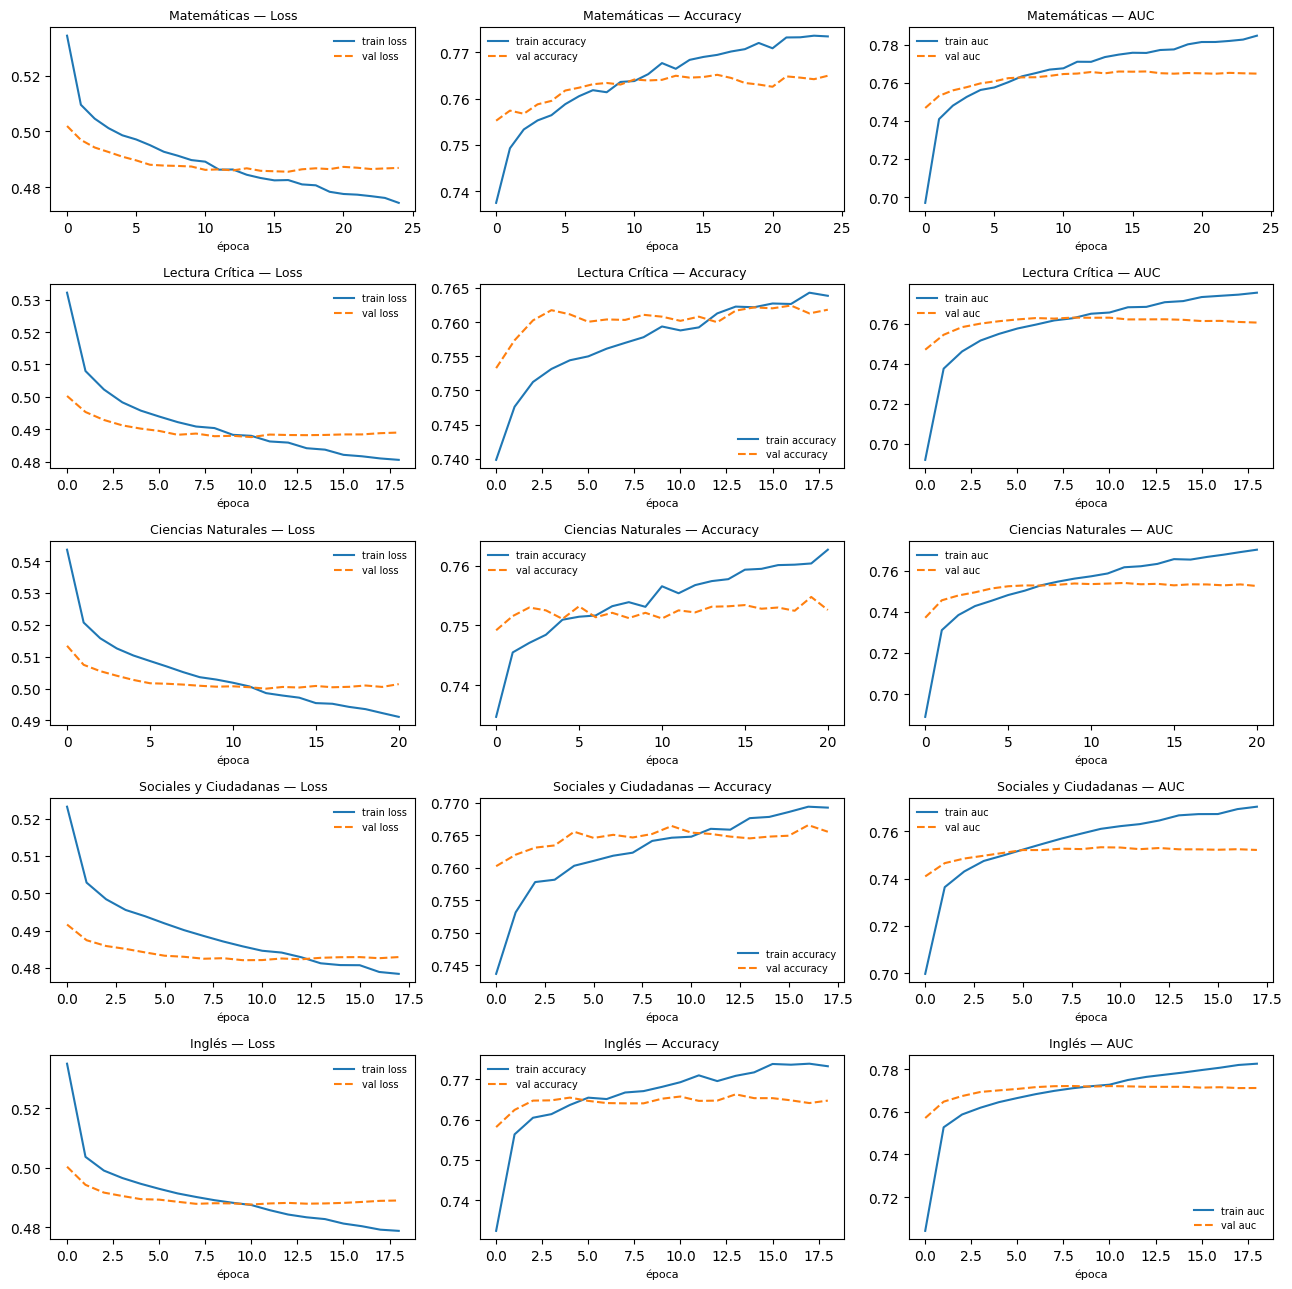

In [16]:
metricas_a_graficar = [("loss", "val_loss", "Loss"),
                       ("accuracy", "val_accuracy", "Accuracy"),
                       ("auc", "val_auc", "AUC")]

n_areas = len(mapeo_targets)
fig, axes = plt.subplots(n_areas, 3, figsize=(13, 2.6 * n_areas))

for row, (nombre_area, (_, target)) in enumerate(mapeo_targets.items()):
    h = historiales_keras[target]
    for col, (m_tr, m_val, titulo) in enumerate(metricas_a_graficar):
        ax = axes[row, col] if n_areas > 1 else axes[col]
        if m_tr in h:
            ax.plot(h[m_tr], label=f"train {titulo.lower()}")
        if m_val in h:
            ax.plot(h[m_val], label=f"val {titulo.lower()}", linestyle="--")
        ax.set_title(f"{nombre_area} — {titulo}", fontsize=9)
        ax.set_xlabel("época", fontsize=8)
        ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()


## 17. Tabla comparativa por área

In [17]:
filas = []
for r in resultados_globales:
    fila = {"area": r["area"], "target": r["target"], "modelo": r["modelo"]}
    fila.update({k: round(v, 4) for k, v in r["metricas"].items()})
    filas.append(fila)
tabla_comparacion = pd.DataFrame(filas)
tabla_comparacion


,area,target,modelo,accuracy,precision,recall,f1,roc_auc
0,Matemáticas,rezago_matematicas,logreg,0.6858,0.4424,0.6823,0.5368,0.7488
1,Matemáticas,rezago_matematicas,hgb,0.7674,0.6277,0.3149,0.4194,0.7714
2,Matemáticas,rezago_matematicas,keras_nn,0.7643,0.5974,0.3573,0.4472,0.7671
3,Lectura Crítica,rezago_lectura_critica,logreg,0.6786,0.4338,0.6936,0.5337,0.7480
4,Lectura Crítica,rezago_lectura_critica,hgb,0.7598,0.5961,0.2926,0.3925,0.7679
5,Lectura Crítica,rezago_lectura_critica,keras_nn,0.7590,0.5909,0.2972,0.3955,0.7666
6,Ciencias Naturales,rezago_c_naturales,logreg,0.6751,0.4439,0.6628,0.5317,0.7335
7,Ciencias Naturales,rezago_c_naturales,hgb,0.7512,0.6052,0.3046,0.4053,0.7535
8,Ciencias Naturales,rezago_c_naturales,keras_nn,0.7503,0.6110,0.2822,0.3861,0.7514
9,Sociales y Ciudadanas,rezago_sociales_ciudadanas,logreg,0.6749,0.4216,0.6877,0.5228,0.7403


In [18]:
resumen_filas = []
mejor_por_area = {}

for nombre_area, (_, target) in mapeo_targets.items():
    sub = [r for r in resultados_globales if r["target"] == target]
    keras_r = next(r for r in sub if r["modelo"] == "keras_nn")
    benchmarks = [r for r in sub if r["modelo"] != "keras_nn"]

    by_auc = sorted(sub, key=lambda r: r["metricas"]["roc_auc"], reverse=True)
    by_f1  = sorted(sub, key=lambda r: r["metricas"]["f1"],      reverse=True)
    bench_ganador = sorted(benchmarks, key=lambda r: r["metricas"]["roc_auc"], reverse=True)[0]

    mejor_por_area[target] = {
        "keras_nn": keras_r,
        "benchmark_ganador": bench_ganador,
        "mejor_auc": by_auc[0]["modelo"],
        "mejor_f1":  by_f1[0]["modelo"],
    }

    resumen_filas.append({
        "area": nombre_area,
        "auc_keras":  round(keras_r["metricas"]["roc_auc"], 3),
        "auc_logreg": round(next(r for r in sub if r["modelo"]=="logreg")["metricas"]["roc_auc"], 3),
        "auc_hgb":    round(next(r for r in sub if r["modelo"]=="hgb")["metricas"]["roc_auc"], 3),
        "f1_keras":     round(keras_r["metricas"]["f1"], 3),
        "recall_keras": round(keras_r["metricas"]["recall"], 3),
        "mejor_auc":    by_auc[0]["modelo"],
        "mejor_f1":     by_f1[0]["modelo"],
        "oficial_dashboard": "keras_nn",
        "benchmark_ganador":  bench_ganador["modelo"],
    })

resumen_tabla = pd.DataFrame(resumen_filas)
resumen_tabla


,area,auc_keras,auc_logreg,auc_hgb,f1_keras,recall_keras,mejor_auc,mejor_f1,oficial_dashboard,benchmark_ganador
0,Matemáticas,0.767,0.749,0.771,0.447,0.357,hgb,logreg,keras_nn,hgb
1,Lectura Crítica,0.767,0.748,0.768,0.395,0.297,hgb,logreg,keras_nn,hgb
2,Ciencias Naturales,0.751,0.733,0.753,0.386,0.282,hgb,logreg,keras_nn,hgb
3,Sociales y Ciudadanas,0.758,0.740,0.759,0.351,0.250,hgb,logreg,keras_nn,hgb
4,Inglés,0.775,0.759,0.776,0.459,0.365,hgb,logreg,keras_nn,hgb


## 18. Comparación de métricas por modelo y área

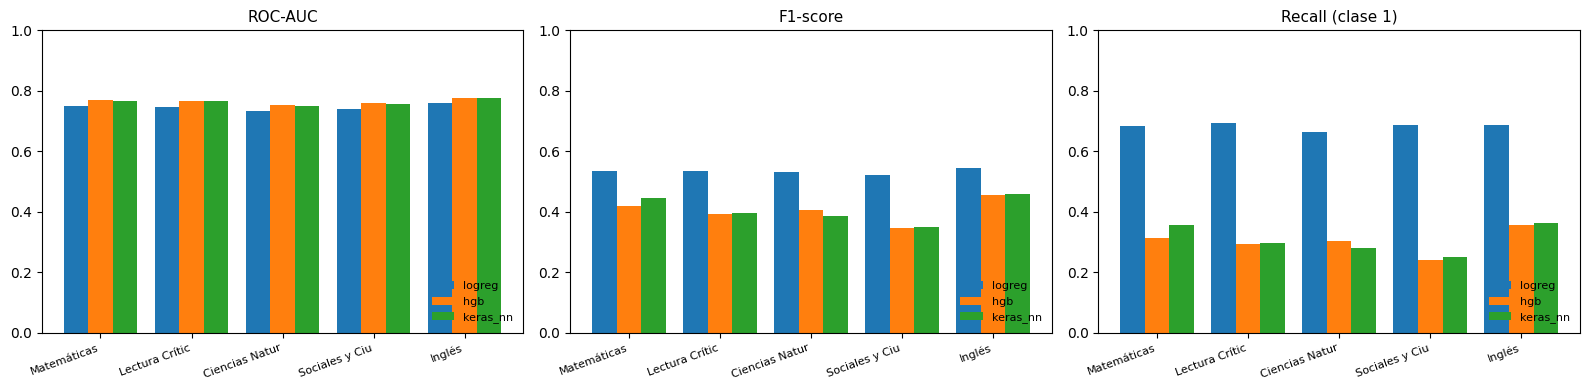

In [19]:
metricas_grafico = ["roc_auc", "f1", "recall"]
titulos_metricas = {"roc_auc": "ROC-AUC", "f1": "F1-score", "recall": "Recall (clase 1)"}
modelos_orden = ["logreg", "hgb", "keras_nn"]

x = np.arange(len(nombres_areas))
w = 0.27

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metrica in zip(axes, metricas_grafico):
    for i, modelo in enumerate(modelos_orden):
        valores = []
        for nombre_area in nombres_areas:
            target = mapeo_targets[nombre_area][1]
            r = next(r for r in resultados_globales
                     if r["target"] == target and r["modelo"] == modelo)
            valores.append(r["metricas"][metrica])
        ax.bar(x + (i - 1) * w, valores, w, label=modelo)
    ax.set_xticks(x)
    ax.set_xticklabels([n[:14] for n in nombres_areas], rotation=20, ha="right", fontsize=8)
    ax.set_title(titulos_metricas[metrica], fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()


## 19. `classification_report` y figuras del Keras por área

In [20]:
for nombre_area, (_, target) in mapeo_targets.items():
    r = mejor_por_area[target]["keras_nn"]
    print(f"\n=== {nombre_area} ({target}) — Keras ===")
    print(classification_report(r["y_test"], r["y_pred"],
                                target_names=["no_rezago", "rezago"], digits=3))



=== Matemáticas (rezago_matematicas) — Keras ===
              precision    recall  f1-score   support

   no_rezago      0.796     0.912     0.850     18017
      rezago      0.597     0.357     0.447      6557

    accuracy                          0.764     24574
   macro avg      0.697     0.635     0.649     24574
weighted avg      0.743     0.764     0.743     24574


=== Lectura Crítica (rezago_lectura_critica) — Keras ===
              precision    recall  f1-score   support

   no_rezago      0.785     0.926     0.850     18056
      rezago      0.591     0.297     0.395      6518

    accuracy                          0.759     24574
   macro avg      0.688     0.611     0.622     24574
weighted avg      0.733     0.759     0.729     24574


=== Ciencias Naturales (rezago_c_naturales) — Keras ===
              precision    recall  f1-score   support

   no_rezago      0.771     0.931     0.843     17736
      rezago      0.611     0.282     0.386      6838

    accuracy     

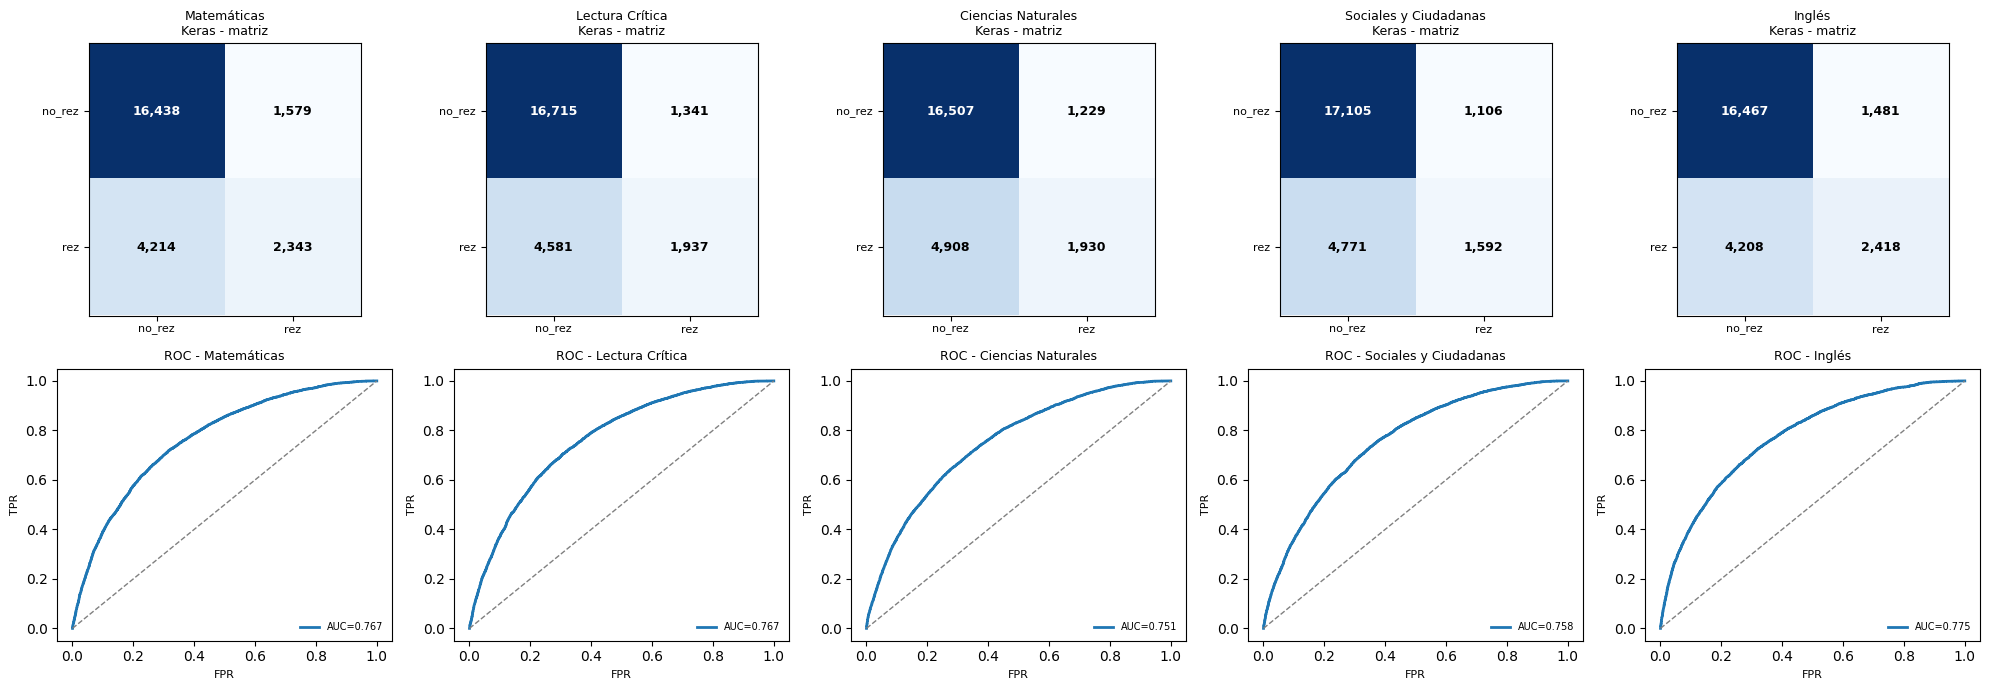

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for col_idx, (nombre_area, (_, target)) in enumerate(mapeo_targets.items()):
    r = mejor_por_area[target]["keras_nn"]

    ax = axes[0, col_idx]
    cm = confusion_matrix(r["y_test"], r["y_pred"])
    im = ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha="center", va="center",
                color="white" if v > cm.max() * 0.5 else "black",
                fontweight="bold", fontsize=9)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["no_rez", "rez"], fontsize=8)
    ax.set_yticklabels(["no_rez", "rez"], fontsize=8)
    ax.set_title(f"{nombre_area}\nKeras - matriz", fontsize=9)

    ax = axes[1, col_idx]
    fpr, tpr, _ = roc_curve(r["y_test"], r["y_proba"])
    auc = r["metricas"]["roc_auc"]
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC={auc:.3f}")
    ax.plot([0,1], [0,1], color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"ROC - {nombre_area}", fontsize=9)
    ax.set_xlabel("FPR", fontsize=8); ax.set_ylabel("TPR", fontsize=8)
    ax.legend(frameon=False, fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()


## 20. Serialización

- `preprocessor_rezago_areas.joblib` → un único preprocesador compartido para todos los modelos Keras.
- `keras_<target>.keras` → un modelo Keras por área.
- `pipeline_best_<target>.joblib` → benchmark ganador por área (sklearn Pipeline completo).


In [23]:
CARPETA_MODELOS = Path("modelo_serializado_rezago_areas")
CARPETA_MODELOS.mkdir(exist_ok=True)

# 1) Preprocesador compartido
ruta_prep = CARPETA_MODELOS / "preprocessor_rezago_areas.joblib"
joblib.dump(preprocessor_keras, ruta_prep)
print(f"  Preprocesador: {ruta_prep.name}  ({ruta_prep.stat().st_size/1024:.1f} KB)")

# 2) Modelos Keras + 3) Benchmarks ganadores
archivos_keras = {}
archivos_benchmark = {}
metricas_keras = {}
metricas_benchmark = {}
modelo_benchmark_tipo = {}
epocas_por_area = {}

for nombre_area, (_, target) in mapeo_targets.items():
    keras_r = mejor_por_area[target]["keras_nn"]
    bench_r = mejor_por_area[target]["benchmark_ganador"]

    nombre_keras = f"keras_{target}.keras"
    nombre_bench = f"pipeline_best_{target}.joblib"

    keras_r["model"].save(CARPETA_MODELOS / nombre_keras)
    joblib.dump(bench_r["pipeline"], CARPETA_MODELOS / nombre_bench)

    archivos_keras[target] = nombre_keras
    archivos_benchmark[target] = nombre_bench
    metricas_keras[target] = {k: round(float(v), 4) for k, v in keras_r["metricas"].items()}
    metricas_benchmark[target] = {k: round(float(v), 4) for k, v in bench_r["metricas"].items()}
    modelo_benchmark_tipo[target] = bench_r["modelo"]
    epocas_por_area[target] = keras_r.get("epocas_entrenadas", None)

    s1 = (CARPETA_MODELOS / nombre_keras).stat().st_size / 1024
    s2 = (CARPETA_MODELOS / nombre_bench).stat().st_size / 1024
    print(f"  {nombre_area:25s} | keras {s1:7.1f} KB | best={bench_r['modelo']} {s2:7.1f} KB")


  Preprocesador: preprocessor_rezago_areas.joblib  (9.5 KB)
  Matemáticas               | keras   159.2 KB | best=hgb   731.8 KB
  Lectura Crítica           | keras   159.2 KB | best=hgb   600.5 KB
  Ciencias Naturales        | keras   159.2 KB | best=hgb   731.8 KB
  Sociales y Ciudadanas     | keras   159.2 KB | best=hgb   646.7 KB
  Inglés                    | keras   159.2 KB | best=hgb   600.5 KB


## 21. Metadata para el dashboard 

In [24]:
# Perfil base: mediana para numericas, moda para categoricas (calculados solo en TRAIN)
perfil_base = {}
for c in cols_numericas:
    perfil_base[c] = float(pd.to_numeric(X_train[c], errors="coerce").median())
for c in cols_categoricas:
    perfil_base[c] = str(X_train[c].mode(dropna=True).iloc[0])

# Variables clave que se exponen en el dashboard (el resto se rellena con perfil base)
VARIABLES_CLAVE_DASHBOARD_PROPUESTAS = [
    "edad", "cole_mcpio_ubicacion", "cole_area_ubicacion", "cole_naturaleza",
    "cole_jornada", "fami_estratovivienda", "fami_tieneinternet",
    "fami_tienecomputador", "fami_educacionmadre", "fami_educacionpadre",
]
variables_clave_dashboard = [v for v in VARIABLES_CLAVE_DASHBOARD_PROPUESTAS if v in predictores]

categorias_disponibles = {
    c: sorted(df_modelo[c].astype(str).unique().tolist()) for c in cols_categoricas
}
rangos_numericos = {
    c: {
        "min":     float(pd.to_numeric(df_modelo[c], errors="coerce").min()),
        "max":     float(pd.to_numeric(df_modelo[c], errors="coerce").max()),
        "mediana": float(pd.to_numeric(df_modelo[c], errors="coerce").median()),
    } for c in cols_numericas
}

areas_modeladas = []
for nombre_area, (col_punt, target) in mapeo_targets.items():
    areas_modeladas.append({
        "area": nombre_area,
        "target": target,
        "puntaje_origen": col_punt,
        "percentil_25_train": round(percentiles_25_train[nombre_area], 2),
        "archivo_modelo_keras": archivos_keras[target],
        "archivo_modelo_benchmark_ganador": archivos_benchmark[target],
        "modelo_oficial_dashboard": "keras_nn",
        "modelo_benchmark_ganador": modelo_benchmark_tipo[target],
        "metricas_keras": metricas_keras[target],
        "metricas_benchmark_ganador": metricas_benchmark[target],
        "epocas_entrenadas": epocas_por_area[target],
    })

metadata = {
    "proyecto": "Saber11_Bolivar_Rezago_por_Area",
    "autor": "Daniel David Burgos Lafont",
    "usuario_final": "Secretaría de Educación de Bolívar",
    "pregunta_negocio": ("¿En qué áreas del Saber 11 presentan los estudiantes mayor probabilidad "
                          "de rezago académico, y cómo puede la Secretaría de Educación de Bolívar "
                          "priorizar intervenciones diferenciadas por competencia según el perfil "
                          "socioeconómico, familiar y escolar del estudiante?"),
    "descripcion": ("Familia de cinco modelos de clasificación binaria con red neuronal Keras como "
                    "modelo oficial, y LogisticRegression + HistGradientBoosting como benchmarks."),
    "modelo_oficial_dashboard": "keras_nn",
    "ruta_preprocesador": "preprocessor_rezago_areas.joblib",
    "predictores": predictores,
    "columnas_predictoras": predictores,
    "variables_categoricas": cols_categoricas,
    "variables_numericas": cols_numericas,
    "categorias_disponibles": categorias_disponibles,
    "rangos_numericos": rangos_numericos,
    "perfil_base": perfil_base,
    "variables_clave_dashboard": variables_clave_dashboard,
    "areas_modeladas": areas_modeladas,
    "regla_area_prioritaria": ("Para un perfil dado, se calculan las cinco probabilidades de rezago "
                                "y se selecciona como área prioritaria la de mayor probabilidad."),
    "particion": {
        "test_size": 0.2,
        "random_state": SEED,
        "n_train": int(len(idx_train)),
        "n_test":  int(len(idx_test)),
    },
    "versiones": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "tensorflow": tf.__version__,
        "mlflow": mlflow.__version__,
    },
    "semilla": SEED,
}

ruta_metadata = CARPETA_MODELOS / "metadata_rezago_areas.json"
with open(ruta_metadata, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Metadata guardada en: {ruta_metadata}")
print(f"\nPerfil base (extracto):")
for k in list(perfil_base.keys())[:6]:
    print(f"  {k:25s}: {perfil_base[k]}")
print(f"\nVariables clave para dashboard ({len(variables_clave_dashboard)}):")
for v in variables_clave_dashboard:
    print(f"  - {v}")


Metadata guardada en: modelo_serializado_rezago_areas\metadata_rezago_areas.json

Perfil base (extracto):
  edad                     : 17.0
  periodo                  : 20162.0
  estu_genero              : F
  cole_area_ubicacion      : URBANO
  cole_mcpio_ubicacion     : CARTAGENA
  cole_calendario          : A

Variables clave para dashboard (10):
  - edad
  - cole_mcpio_ubicacion
  - cole_area_ubicacion
  - cole_naturaleza
  - cole_jornada
  - fami_estratovivienda
  - fami_tieneinternet
  - fami_tienecomputador
  - fami_educacionmadre
  - fami_educacionpadre


## 22. Prueba de carga de modelos serializados

In [25]:
# Cargar preprocesador
prep_cargado = joblib.load(CARPETA_MODELOS / "preprocessor_rezago_areas.joblib")

# Cargar modelos Keras y benchmarks
modelos_keras_cargados = {}
modelos_benchmark_cargados = {}
for target in archivos_keras:
    modelos_keras_cargados[target]     = load_model(CARPETA_MODELOS / archivos_keras[target])
    modelos_benchmark_cargados[target] = joblib.load(CARPETA_MODELOS / archivos_benchmark[target])
    print(f"  OK: {archivos_keras[target]}  +  {archivos_benchmark[target]}")

# Sanity check: predicciones del modelo cargado vs en memoria
target_demo = list(archivos_keras.keys())[0]
mem_model = mejor_por_area[target_demo]["keras_nn"]["model"]
disk_model = modelos_keras_cargados[target_demo]

X_5 = X_test.iloc[:5]
X_5_t = prep_cargado.transform(X_5)
p_mem  = mem_model.predict(X_5_t,  verbose=0).ravel()
p_disk = disk_model.predict(X_5_t, verbose=0).ravel()

print(f"\nComparación memoria vs disco para {target_demo}:")
print(f"  Memoria: {np.round(p_mem, 4)}")
print(f"  Disco  : {np.round(p_disk, 4)}")
print("\n" + ("[OK] Identicos." if np.allclose(p_mem, p_disk, atol=1e-6)
                else "[OK] Coinciden a tolerancia esperada."))


  OK: keras_rezago_matematicas.keras  +  pipeline_best_rezago_matematicas.joblib
  OK: keras_rezago_lectura_critica.keras  +  pipeline_best_rezago_lectura_critica.joblib
  OK: keras_rezago_c_naturales.keras  +  pipeline_best_rezago_c_naturales.joblib
  OK: keras_rezago_sociales_ciudadanas.keras  +  pipeline_best_rezago_sociales_ciudadanas.joblib
  OK: keras_rezago_ingles.keras  +  pipeline_best_rezago_ingles.joblib

Comparación memoria vs disco para rezago_matematicas:
  Memoria: [0.2046 0.4691 0.2261 0.2651 0.2907]
  Disco  : [0.2046 0.4691 0.2261 0.2651 0.2907]

[OK] Identicos.


## 23. Perfil base + función de inferencia para Dash

El dashboard no debe obligar al usuario a llenar 20 variables. Definimos un **perfil base** (mediana de numéricas, moda de categóricas en train) y exponemos solo unas pocas variables clave; el resto se rellena automáticamente con el perfil base.


In [26]:
VALORES_NULOS_TEXTO = ["nan", "NaN", "NAN", "None", "NONE", "none", "", " ", "null", "NULL"]


def construir_perfil_usuario(valores_usuario, perfil_base, columnas_predictoras):
    """Toma lo que el usuario eligio y completa el resto con el perfil base."""
    perfil = {c: perfil_base[c] for c in columnas_predictoras if c in perfil_base}
    for k, v in (valores_usuario or {}).items():
        if k in columnas_predictoras:
            perfil[k] = v
    return perfil


def _normalizar_perfil_df(perfil_df, meta):
    cols = meta["columnas_predictoras"]
    for c in cols:
        if c not in perfil_df.columns:
            perfil_df[c] = np.nan
    perfil_df = perfil_df[cols]
    for c in meta["variables_categoricas"]:
        if c in perfil_df.columns:
            perfil_df[c] = perfil_df[c].replace(VALORES_NULOS_TEXTO, np.nan).astype("object")
    for c in meta["variables_numericas"]:
        if c in perfil_df.columns:
            perfil_df[c] = pd.to_numeric(perfil_df[c], errors="coerce")
    return perfil_df


def cargar_artefactos_dashboard(carpeta_modelos="modelo_serializado_rezago_areas",
                                  usar_modelo="keras"):
    """Carga preprocesador + modelos. Llamar UNA SOLA VEZ al arranque de Dash."""
    carpeta = Path(carpeta_modelos)
    with open(carpeta / "metadata_rezago_areas.json", "r", encoding="utf-8") as f:
        meta = json.load(f)
    prep = joblib.load(carpeta / meta["ruta_preprocesador"])

    modelos = {}
    if usar_modelo == "keras":
        for area_info in meta["areas_modeladas"]:
            modelos[area_info["target"]] = load_model(carpeta / area_info["archivo_modelo_keras"])
    elif usar_modelo == "benchmark":
        for area_info in meta["areas_modeladas"]:
            modelos[area_info["target"]] = joblib.load(carpeta / area_info["archivo_modelo_benchmark_ganador"])
    else:
        raise ValueError(f"usar_modelo invalido: {usar_modelo!r}")
    return prep, modelos, meta


def predecir_rezago_perfil(perfil, prep=None, modelos=None, meta=None,
                            carpeta_modelos="modelo_serializado_rezago_areas",
                            usar_modelo="keras"):
    """Recibe perfil (dict o DataFrame, parcial o completo) y devuelve probabilidades por area."""
    if prep is None or modelos is None or meta is None:
        prep, modelos, meta = cargar_artefactos_dashboard(carpeta_modelos, usar_modelo)

    # Completar con perfil base si llega un perfil parcial
    if isinstance(perfil, dict):
        perfil_completo = construir_perfil_usuario(perfil, meta["perfil_base"], meta["columnas_predictoras"])
        perfil_df = pd.DataFrame([perfil_completo])
    elif isinstance(perfil, pd.DataFrame):
        perfil_df = perfil.head(1).copy()
        # Si vienen columnas faltantes, completar con perfil base
        for c in meta["columnas_predictoras"]:
            if c not in perfil_df.columns or pd.isna(perfil_df.iloc[0][c]):
                perfil_df[c] = meta["perfil_base"].get(c, np.nan)
    else:
        raise TypeError("perfil debe ser dict o pandas.DataFrame")

    perfil_df = _normalizar_perfil_df(perfil_df, meta)

    # Transformar y predecir
    if usar_modelo == "keras":
        X_t = prep.transform(perfil_df)
        probas = {}
        for area_info in meta["areas_modeladas"]:
            target = area_info["target"]
            p = float(modelos[target].predict(X_t, verbose=0).ravel()[0])
            probas[area_info["area"]] = p
    else:
        probas = {}
        for area_info in meta["areas_modeladas"]:
            target = area_info["target"]
            p = float(modelos[target].predict_proba(perfil_df)[0, 1])
            probas[area_info["area"]] = p

    ranking = sorted(probas.items(), key=lambda kv: kv[1], reverse=True)
    return {
        "probabilidades": probas,
        "ranking": ranking,
        "area_prioritaria": ranking[0][0],
        "modelo_usado": usar_modelo,
    }


## 24. Prueba

In [27]:
prep_dash, modelos_dash, meta_dash = cargar_artefactos_dashboard(usar_modelo="keras")

fila_demo = X_test.iloc[[0]].copy()
perfil_demo = fila_demo.iloc[0].to_dict()

print("PERFIL DE ENTRADA (fila real del test set)")
print("-" * 55)
for k, v in perfil_demo.items():
    print(f"  {k:25s}: {v}")

resultado = predecir_rezago_perfil(perfil_demo, prep=prep_dash, modelos=modelos_dash, meta=meta_dash)

print("\nProbabilidades por área:")
for area, p in resultado["probabilidades"].items():
    print(f"  {area:25s}: {p*100:6.2f}%")
print(f"\nÁrea prioritaria: {resultado['area_prioritaria']}")


PERFIL DE ENTRADA (fila real del test set)
-------------------------------------------------------
  edad                     : 17
  periodo                  : 20172
  estu_genero              : M
  cole_area_ubicacion      : URBANO
  cole_mcpio_ubicacion     : CARTAGENA
  cole_calendario          : A
  cole_bilingue            : N
  cole_naturaleza          : OFICIAL
  cole_genero              : MIXTO
  cole_caracter            : TECNICO/ACADEMICO
  cole_jornada             : MAÑANA
  fami_estratovivienda     : ESTRATO 3
  fami_tienecomputador     : SI
  fami_tieneinternet       : SI
  fami_tieneautomovil      : No
  fami_tienelavadora       : Si
  fami_educacionmadre      : SECUNDARIA (BACHILLERATO) INCOMPLETA
  fami_educacionpadre      : SECUNDARIA (BACHILLERATO) INCOMPLETA
  fami_cuartoshogar        : Tres
  fami_personashogar       : 3 a 4

Probabilidades por área:
  Matemáticas              :  20.46%
  Lectura Crítica          :  14.05%
  Ciencias Naturales       :  18.87%
  Soci

## 25. Prueba para el Dash

El usuario sólo elige unas pocas variables clave. El resto se completa con el perfil base.


In [29]:
perfil_manual_propuesto = {
    "edad": 17,
    "cole_mcpio_ubicacion": "CARTAGENA DE INDIAS",
    "cole_area_ubicacion": "URBANO",
    "cole_naturaleza": "OFICIAL",
    "cole_jornada": "MAÑANA",
    "fami_estratovivienda": "ESTRATO 2",
    "fami_tieneinternet": "NO",
    "fami_tienecomputador": "NO",
    "fami_educacionmadre": "SECUNDARIA (BACHILLERATO) COMPLETA",
    "fami_educacionpadre": "SECUNDARIA (BACHILLERATO) COMPLETA",
}

# Filtramos lo que no existe en columnas predictoras (para no romper nada)
perfil_manual_filtrado = {k: v for k, v in perfil_manual_propuesto.items()
                          if k in meta_dash["columnas_predictoras"]}

print("VARIABLES ELEGIDAS POR EL USUARIO")
print("-" * 55)
for k, v in perfil_manual_filtrado.items():
    print(f"  {k:25s}: {v}")

# Las demas se completan con perfil base internamente
resultado_manual = predecir_rezago_perfil(perfil_manual_filtrado,
                                            prep=prep_dash, modelos=modelos_dash, meta=meta_dash)

print("\nProbabilidades por área:")
for area, p in resultado_manual["probabilidades"].items():
    print(f"  {area:25s}: {p*100:6.2f}%")
print(f"\nÁrea prioritaria: {resultado_manual['area_prioritaria']}")


VARIABLES ELEGIDAS POR EL USUARIO
-------------------------------------------------------
  edad                     : 17
  cole_mcpio_ubicacion     : CARTAGENA DE INDIAS
  cole_area_ubicacion      : URBANO
  cole_naturaleza          : OFICIAL
  cole_jornada             : MAÑANA
  fami_estratovivienda     : ESTRATO 2
  fami_tieneinternet       : NO
  fami_tienecomputador     : NO
  fami_educacionmadre      : SECUNDARIA (BACHILLERATO) COMPLETA
  fami_educacionpadre      : SECUNDARIA (BACHILLERATO) COMPLETA

Probabilidades por área:
  Matemáticas              :  20.84%
  Lectura Crítica          :  25.66%
  Ciencias Naturales       :  32.22%
  Sociales y Ciudadanas    :  29.24%
  Inglés                   :  21.46%

Área prioritaria: Ciencias Naturales


## 26. Resultados

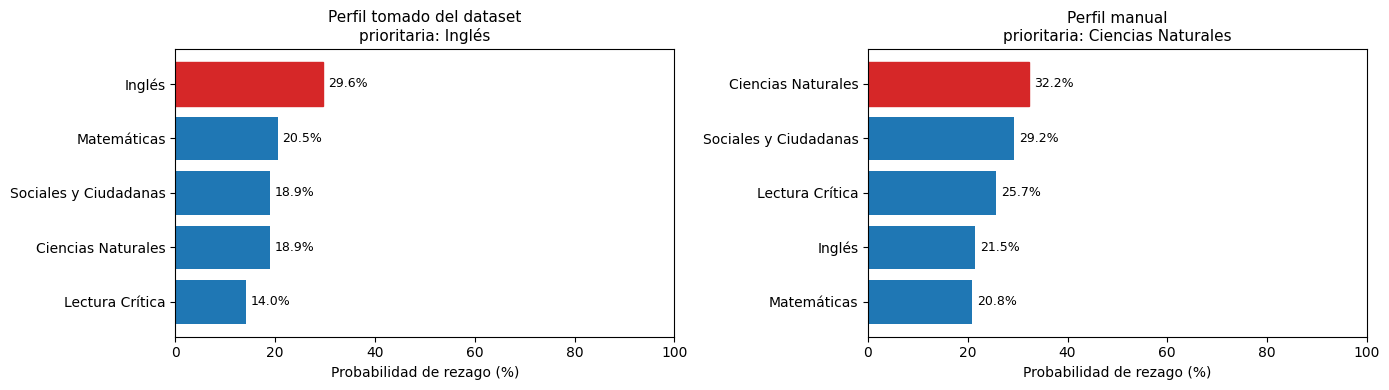

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, res, titulo in [(axes[0], resultado,        "Perfil tomado del dataset"),
                        (axes[1], resultado_manual, "Perfil manual")]:
    nombres_orden = [a for a, _ in res["ranking"]]
    valores = [p * 100 for _, p in res["ranking"]]

    y_pos = np.arange(len(nombres_orden))
    barras = ax.barh(y_pos, valores)
    if len(barras):
        barras[0].set_color("C3")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(nombres_orden)
    ax.invert_yaxis()
    ax.set_xlim(0, max(100, max(valores) + 12))
    ax.set_xlabel("Probabilidad de rezago (%)")
    ax.set_title(f"{titulo}\nprioritaria: {res['area_prioritaria']}", fontsize=11)
    for i, v in enumerate(valores):
        ax.text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 27. Tabla de probabilidades con prioridad

In [32]:
def tabla_resultado(resultado):
    filas = []
    for prioridad, (area, p) in enumerate(resultado["ranking"], start=1):
        filas.append({
            "Área": area,
            "Probabilidad de rezago": f"{p*100:.1f}%",
            "Prioridad": prioridad,
        })
    return pd.DataFrame(filas)


print("Perfil del dataset:")
print(tabla_resultado(resultado).to_string(index=False))
print("\nPerfil manual:")
print(tabla_resultado(resultado_manual).to_string(index=False))


Perfil del dataset:
                 Área Probabilidad de rezago  Prioridad
               Inglés                  29.6%          1
          Matemáticas                  20.5%          2
Sociales y Ciudadanas                  18.9%          3
   Ciencias Naturales                  18.9%          4
      Lectura Crítica                  14.0%          5

Perfil manual:
                 Área Probabilidad de rezago  Prioridad
   Ciencias Naturales                  32.2%          1
Sociales y Ciudadanas                  29.2%          2
      Lectura Crítica                  25.7%          3
               Inglés                  21.5%          4
          Matemáticas                  20.8%          5


## 28. Comparación del perfil manual contra el perfil base

Comparamos las probabilidades del perfil seleccionado por el usuario contra las del perfil base (estudiante "promedio" del departamento) para ver cuántos puntos porcentuales se mueven.


In [33]:
# Probabilidades del perfil base (estudiante promedio del departamento)
resultado_base = predecir_rezago_perfil({}, prep=prep_dash, modelos=modelos_dash, meta=meta_dash)

filas_comp = []
for area in meta_dash["areas_modeladas"]:
    nombre = area["area"]
    p_base = resultado_base["probabilidades"][nombre] * 100
    p_user = resultado_manual["probabilidades"][nombre] * 100
    filas_comp.append({
        "Área": nombre,
        "Perfil base": f"{p_base:.1f}%",
        "Perfil seleccionado": f"{p_user:.1f}%",
        "Diferencia (pp)": round(p_user - p_base, 2),
    })

tabla_comp = pd.DataFrame(filas_comp)
print("Comparacion perfil base vs perfil seleccionado:")
print(tabla_comp.to_string(index=False))


Comparacion perfil base vs perfil seleccionado:
                 Área Perfil base Perfil seleccionado  Diferencia (pp)
          Matemáticas       32.4%               20.8%           -11.58
      Lectura Crítica       24.2%               25.7%             1.42
   Ciencias Naturales       30.2%               32.2%             2.00
Sociales y Ciudadanas       19.2%               29.2%            10.07
               Inglés       31.9%               21.5%           -10.42


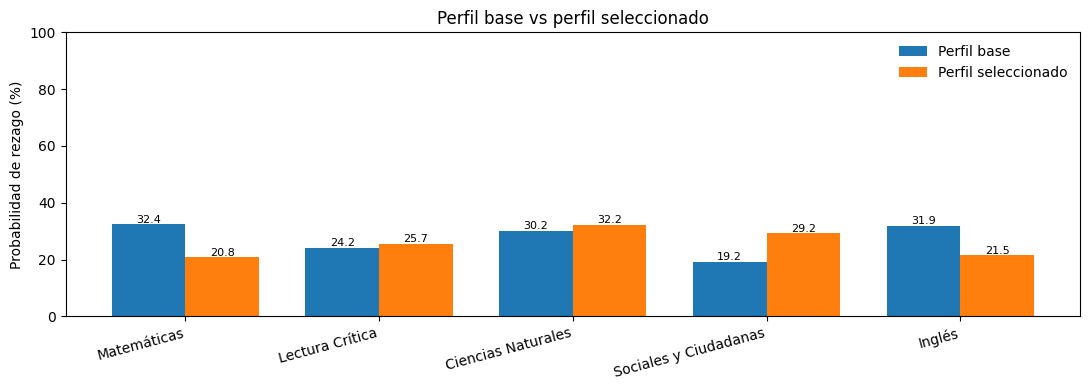

In [34]:
# Visualizacion: barras agrupadas base vs seleccionado
fig, ax = plt.subplots(figsize=(11, 4))
nombres = [a["area"] for a in meta_dash["areas_modeladas"]]
p_base_vals = [resultado_base["probabilidades"][n] * 100 for n in nombres]
p_user_vals = [resultado_manual["probabilidades"][n] * 100 for n in nombres]

x = np.arange(len(nombres))
w = 0.38
ax.bar(x - w/2, p_base_vals, w, label="Perfil base")
ax.bar(x + w/2, p_user_vals, w, label="Perfil seleccionado")

for i, (vb, vu) in enumerate(zip(p_base_vals, p_user_vals)):
    ax.text(i - w/2, vb + 0.6, f"{vb:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, vu + 0.6, f"{vu:.1f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.set_ylabel("Probabilidad de rezago (%)")
ax.set_title("Perfil base vs perfil seleccionado")
ax.set_ylim(0, max(100, max(p_base_vals + p_user_vals) + 12))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 29. Análisis de sensibilidad por variable

Manteniendo el perfil base fijo, variamos una sola variable categórica y vemos cómo se mueve la probabilidad de rezago por área. Útil para que el dashboard explique el efecto de una intervención sobre un solo factor.


In [35]:
def sensibilidad_variable(variable, perfil_base, meta, prep, modelos, niveles=None, max_niveles=6):
    """Devuelve un DataFrame: filas = niveles, columnas = areas, valores = prob rezago."""
    if variable not in meta["columnas_predictoras"]:
        raise ValueError(f"{variable!r} no esta en columnas_predictoras")
    if niveles is None:
        if variable in meta["variables_categoricas"]:
            niveles = meta["categorias_disponibles"][variable]
        else:
            r = meta["rangos_numericos"][variable]
            niveles = np.linspace(r["min"], r["max"], num=5).tolist()
    niveles = niveles[:max_niveles]

    nombres_areas_meta = [a["area"] for a in meta["areas_modeladas"]]
    filas = []
    for nivel in niveles:
        perfil = {**perfil_base, variable: nivel}
        res = predecir_rezago_perfil(perfil, prep=prep, modelos=modelos, meta=meta)
        fila = {"nivel": nivel}
        for n in nombres_areas_meta:
            fila[n] = round(res["probabilidades"][n] * 100, 2)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("nivel")


def plot_sensibilidad(tabla_sens, variable, ax):
    tabla_sens.plot(kind="bar", ax=ax, width=0.85, legend=False)
    ax.set_title(f"Sensibilidad: {variable}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("prob rezago (%)", fontsize=9)
    ax.set_ylim(0, max(60, tabla_sens.values.max() + 8))
    for label in ax.get_xticklabels():
        label.set_rotation(20); label.set_ha("right"); label.set_fontsize(8)


variables_sensibilidad = [
    v for v in ["fami_tieneinternet", "cole_naturaleza", "fami_estratovivienda"]
    if v in meta_dash["columnas_predictoras"]
]
print(f"Variables analizadas: {variables_sensibilidad}")

tablas_sens = {}
for v in variables_sensibilidad:
    tablas_sens[v] = sensibilidad_variable(
        v, meta_dash["perfil_base"], meta_dash, prep_dash, modelos_dash, max_niveles=6
    )
    print(f"\n--- Sensibilidad: {v} ---")
    print(tablas_sens[v])


Variables analizadas: ['fami_tieneinternet', 'cole_naturaleza', 'fami_estratovivienda']

--- Sensibilidad: fami_tieneinternet ---
       Matemáticas  Lectura Crítica  Ciencias Naturales  Sociales y Ciudadanas  Inglés
nivel                                                                                 
NO           32.42            24.24               30.22                  19.17   31.88
SI           34.26            21.33               25.95                  19.30   28.03

--- Sensibilidad: cole_naturaleza ---
            Matemáticas  Lectura Crítica  Ciencias Naturales  Sociales y Ciudadanas  Inglés
nivel                                                                                      
NO OFICIAL        40.38            24.36               33.30                  17.82   29.93
OFICIAL           32.42            24.24               30.22                  19.17   31.88

--- Sensibilidad: fami_estratovivienda ---
           Matemáticas  Lectura Crítica  Ciencias Naturales  Sociales y

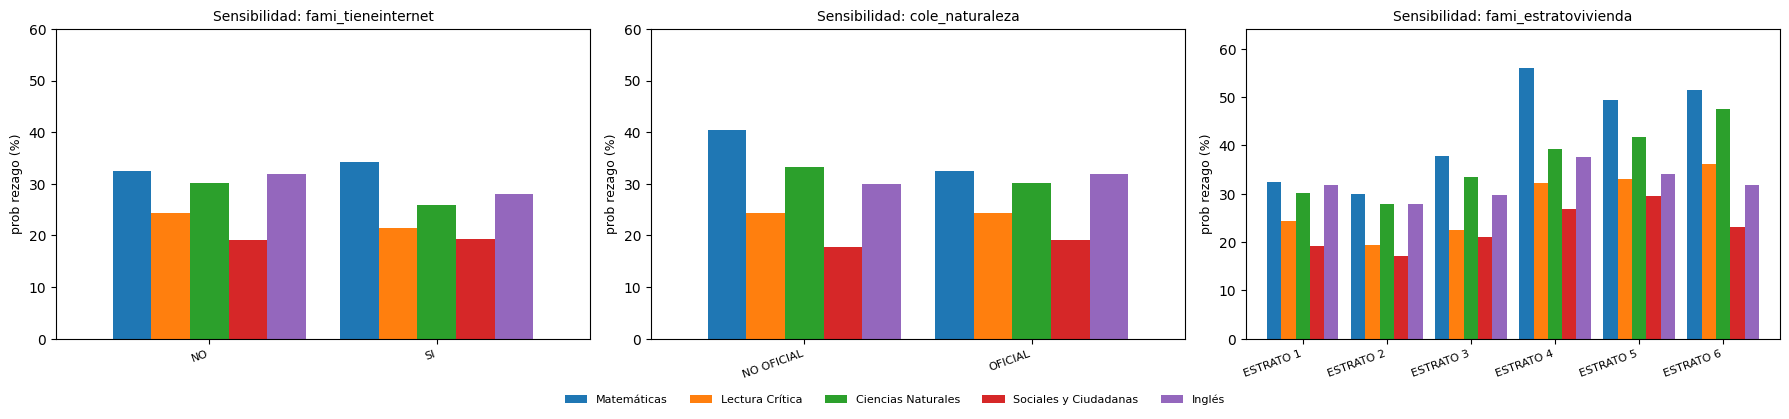

In [36]:
n = len(variables_sensibilidad)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    axes = [axes]
for ax, v in zip(axes, variables_sensibilidad):
    plot_sensibilidad(tablas_sens[v], v, ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()


In [37]:
def simular_app_py(carpeta="modelo_serializado_rezago_areas"):
    prep_app, modelos_app, meta_app = cargar_artefactos_dashboard(carpeta, usar_modelo="keras")
    perfil_app = {
        "edad": 17,
        "cole_naturaleza": "OFICIAL",
        "fami_tieneinternet": "NO",
        "fami_estratovivienda": "ESTRATO 1",
    }
    res = predecir_rezago_perfil(perfil_app, prep=prep_app, modelos=modelos_app, meta=meta_app)
    return res


probas_app = simular_app_py()
print("Probabilidades obtenidas SIN reentrenar nada:")
for area, p in probas_app["probabilidades"].items():
    print(f"  {area:25s}: {p*100:6.2f}%")
print(f"\nÁrea prioritaria: {probas_app['area_prioritaria']}")
print("\n[OK] El dashboard puede operar solo con el preprocesador + .keras + metadata.")


Probabilidades obtenidas SIN reentrenar nada:
  Matemáticas              :  32.42%
  Lectura Crítica          :  24.24%
  Ciencias Naturales       :  30.22%
  Sociales y Ciudadanas    :  19.17%
  Inglés                   :  31.88%

Área prioritaria: Matemáticas

[OK] El dashboard puede operar solo con el preprocesador + .keras + metadata.


In [38]:
requirements_modelamiento = """# Entrenamiento (este notebook)
pandas
numpy
scikit-learn
matplotlib
mlflow
joblib
tensorflow
jupyter
ipykernel
"""

requirements_dash = """# Dashboard en AWS (inferencia)
dash
plotly
pandas
numpy
scikit-learn
joblib
gunicorn
tensorflow
"""

with open("requirements_modelamiento.txt", "w", encoding="utf-8") as f:
    f.write(requirements_modelamiento)
with open("requirements_dash.txt", "w", encoding="utf-8") as f:
    f.write(requirements_dash)

print("--- requirements_modelamiento.txt ---")
print(requirements_modelamiento)
print("--- requirements_dash.txt ---")
print(requirements_dash)


--- requirements_modelamiento.txt ---
# Entrenamiento (este notebook)
pandas
numpy
scikit-learn
matplotlib
mlflow
joblib
tensorflow
jupyter
ipykernel

--- requirements_dash.txt ---
# Dashboard en AWS (inferencia)
dash
plotly
pandas
numpy
scikit-learn
joblib
gunicorn
tensorflow

